<a href="https://colab.research.google.com/github/EmmanuelC-137/Mineria_de_datos/blob/main/Proyecto_mineria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Proyecto de Mineria de datos

# Proyecto Minería de Datos: Reconocimiento de Voz "Luz Inteligente"

**Integrantes:**
- Martin Eduardo Zúñiga Martinez
- Juan Antonio Cabrera Meza
- Emmanuel Hernández Méndez

**Grupo(s):** [6:00–7:00 PM / 8:00–9:00 PM]

**Fecha de entrega:** 25 de mayo de 2026

---

## Índice
1. [Fase 1: Preparación de la Libreta Colab](#fase1)
2. [Fase 2: Adquisición y Procesamiento de Datos](#fase2)
3. [Fase 3: Desarrollo del Modelo y Optimización](#fase3)
4. [Fase 4: Evaluación y Resultados](#fase4)
5. [Conclusiones](#conclusiones)

---

## Introducción Teórica

### Procesamiento de audio
El procesamiento de audio implica la manipulación y análisis de señales acústicas. En el contexto del aprendizaje automático, el audio crudo (una secuencia de amplitudes en el tiempo) es difícil de procesar directamente debido a su alta dimensionalidad y variabilidad. Por ello, se recurre a técnicas de extracción de características.

### Uso de MFCC (Coeficientes Cepstrales en Frecuencia Mel)
Los MFCC son representaciones de características ampliamente utilizadas en el procesamiento del habla. Se basan en la percepción humana del sonido, utilizando la escala Mel, que aproxima la respuesta no lineal del oído humano a diferentes frecuencias. Los MFCC capturan la envolvente espectral de un sonido, lo cual es fundamental para distinguir diferentes fonemas y palabras.

### Redes Neuronales Densas (Perceptrón Multicapa)
Las redes neuronales densas, o completamente conectadas, son arquitecturas donde cada neurona de una capa está conectada a todas las neuronas de la capa siguiente. Son útiles para aprender relaciones complejas no lineales en datos tabulares o características extraídas (como los MFCC aplanados).

<a id='fase1'></a>
## Fase 1: Preparación de la Libreta Colab

### Paso 1.2: Importación de herramientas
Instalamos e importamos las librerías necesarias para el procesamiento de audio y construcción del modelo.

In [33]:
# IMPORTACIÓN DE LIBRERÍAS

# Manejo de archivos y operaciones
import os
import numpy as np
# Procesamiento de audio
import librosa
# TensorFlow y Keras
import tensorflow as tf
# Gráficas
import matplotlib.pyplot as plt
# Google Drive
from google.colab import drive
# División de datos
from sklearn.model_selection import train_test_split
# Normalización
from sklearn.preprocessing import StandardScaler
# Construcción del modelo
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
# Optimizador
from tensorflow.keras.optimizers import Adam
# Callbacks
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)
# Ignorar warnings
import warnings
warnings.filterwarnings('ignore')

<a id='fase2'></a>
## Fase 2: Adquisición y Procesamiento de Datos

### Paso 2.1: Recolección del dataset
Montamos Google Drive para acceder a la carpeta donde están guardados los audios (122 archivos esperados).

In [34]:
# Montar Google Drive
drive.mount('/content/drive')

# Ruta de audios de encender luz
ruta_encendida = '/content/drive/MyDrive/Librosa/encenderluz'

# Ruta de audios de apagar luz
ruta_apagada = '/content/drive/MyDrive/Librosa/apagarluz'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Paso 2.2 y 2.3: Extracción de características (MFCC), Normalización y Padding
Definiremos una función para extraer los MFCC de cada audio, asegurando que todos tengan el mismo tamaño (padding) y normalizando los valores.

In [35]:
# FASE 2.2: EXTRACCIÓN DE CARACTERÍSTICAS
def extract_features(file_path):
    try:

        # Cargar audio
        audio, sample_rate = librosa.load(file_path)

        # Extraer MFCC
        mfccs = librosa.feature.mfcc(
            y=audio,
            sr=sample_rate,
            n_mfcc=20
        )

        # Delta MFCC
        mfccs_delta = librosa.feature.delta(mfccs)

        # Delta-Delta MFCC
        mfccs_delta2 = librosa.feature.delta(
            mfccs,
            order=2
        )

        # Combinar características
        features = np.concatenate([

            np.mean(mfccs, axis=1),
            np.std(mfccs, axis=1),

            np.mean(mfccs_delta, axis=1),
            np.std(mfccs_delta, axis=1),

            np.mean(mfccs_delta2, axis=1),
            np.std(mfccs_delta2, axis=1)

        ])

        return features

    except Exception as e:

        print(f"Error con el archivo {file_path}: {e}")

        return None

In [37]:
# FASE 2.3: NORMALIZACIÓN Y PADDING

# Listas para guardar datos
X_list = []
y_list = []

# Audios de encender luz
print("Cargando audios de Luz Encendida...")

for archivo in os.listdir(ruta_encendida):

    # Verificar formato válido
    if archivo.lower().endswith(
        ('.wav', '.mp3', '.m4a', '.ogg')
    ):

        # Extraer características
        caracteristicas = extract_features(
            os.path.join(ruta_encendida, archivo)
        )

        if caracteristicas is not None:

            X_list.append(caracteristicas)

            # Etiqueta 1 = encender luz
            y_list.append(1)

# Audios apagar luz
print("Cargando audios de Luz Apagada...")
for archivo in os.listdir(ruta_apagada):

    if archivo.lower().endswith(
        ('.wav', '.mp3', '.m4a', '.ogg')
    ):

        caracteristicas = extract_features(
            os.path.join(ruta_apagada, archivo)
        )

        if caracteristicas is not None:

            X_list.append(caracteristicas)

            # Etiqueta 0 = apagar luz
            y_list.append(0)

# Convertir listas a numpy
X = np.array(X_list)
y = np.array(y_list)

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,
    stratify=y
)

# Normalizar datos
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print(f"\nTotal de audios procesados: {len(X)}")

print(f"Audios entrenamiento: {X_train.shape[0]}")

print(f"Audios prueba: {X_test.shape[0]}")

Cargando audios de Luz Encendida...
Cargando audios de Luz Apagada...

Total de audios procesados: 72
Audios entrenamiento: 57
Audios prueba: 15


<a id='fase3'></a>
## Fase 3: Desarrollo del Modelo y Optimización

### Paso 3.1 y 3.2: Arquitectura base y Experimentación (Tuning)
Crearemos una función que nos permita probar diferentes arquitecturas variando el número de capas ocultas y neuronas.

**Justificación de Arquitectura Elegida:**
*Durante la etapa de experimentación se probaron diferentes configuraciones variando el número de capas ocultas y neuronas por capa (1 capa con 32 neuronas, 2 capas con 64 neuronas y 3 capas con 128 neuronas).

Los resultados mostraron que aumentar la complejidad del modelo incrementaba ligeramente la precisión de entrenamiento, pero no mejoraba la precisión de validación, lo que indica presencia de sobreajuste debido al tamaño reducido del dataset.

Por esta razón, el equipo decidió utilizar una arquitectura más simple compuesta por:

- 1 capa oculta
- 32 neuronas
- Activación ReLU
- Capa Dropout del 20%
- Función de salida Sigmoid

Esta configuración ofreció un mejor equilibrio entre simplicidad, estabilidad y capacidad de generalización. Además, se utilizó EarlyStopping para evitar entrenamientos innecesarios y reducir el riesgo de sobreajuste.*

In [38]:
# FASE 3.1: ARQUITECTURA BASE
def create_model(
    num_hidden_layers,
    neurons_per_layer,
    input_shape
):

    # Crear modelo secuencial
    model = Sequential()

    # Primera capa
    model.add(Dense(

        neurons_per_layer,

        activation='relu',

        input_shape=input_shape
    ))

    # Normalización interna
    model.add(BatchNormalization())

    # Evitar sobreajuste
    model.add(Dropout(0.2))

    # Capas ocultas adicionales
    for _ in range(num_hidden_layers - 1):

        model.add(Dense(

            neurons_per_layer,

            activation='relu'
        ))

        model.add(BatchNormalization())

        model.add(Dropout(0.2))

    # Capa de salida
    model.add(Dense(

        1,

        activation='sigmoid'
    ))

    # Optimizador
    opt = Adam(
        learning_rate=0.001
    )

    # Compilar modelo
    model.compile(

        optimizer=opt,

        loss='binary_crossentropy',

        metrics=['accuracy']
    )

    return model

In [39]:
# FASE 3.2: EXPERIMENTACIÓN (TUNING)

# Detectar forma de entrada
forma_entrada = (X_train.shape[1],)

print("\n===== EXPERIMENTACIÓN DE MODELOS =====\n")

# Configuraciones a probar
configuraciones = [

    (1, 32),

    (2, 64),

    (3, 128)
]

# Probar modelos
for capas, neuronas in configuraciones:

    print(
        f"\nProbando modelo: "
        f"{capas} capas y "
        f"{neuronas} neuronas"
    )

    modelo_temp = create_model(
        num_hidden_layers=capas,
        neurons_per_layer=neuronas,
        input_shape=forma_entrada
    )

    # Entrenar modelo
    historia_temp = modelo_temp.fit(
        X_train,
        y_train,
        epochs=10,
        batch_size=8,
        validation_data=(X_test, y_test),
        verbose=0
    )

    # Obtener accuracy final
    train_acc = historia_temp.history['accuracy'][-1]
    val_acc = historia_temp.history['val_accuracy'][-1]
    print(
        f"Accuracy entrenamiento: "
        f"{train_acc:.4f}"
    )
    print(
        f"Accuracy validación: "
        f"{val_acc:.4f}"
    )


===== EXPERIMENTACIÓN DE MODELOS =====


Probando modelo: 1 capas y 32 neuronas
Accuracy entrenamiento: 0.9123
Accuracy validación: 0.7333

Probando modelo: 2 capas y 64 neuronas
Accuracy entrenamiento: 0.9123
Accuracy validación: 0.6000

Probando modelo: 3 capas y 128 neuronas
Accuracy entrenamiento: 0.9474
Accuracy validación: 0.6667


### Paso 3.3: Entrenamiento
Entrenamos el modelo y graficamos la pérdida (Loss) y la precisión (Accuracy).

In [40]:
# Modelo seleccionado después de la experimentación
capas_ocultas = 2
neuronas = 64

# ============================================================================
# FASE 3.3: ENTRENAMIENTO FINAL DEL MEJOR MODELO
# ============================================================================

print(f"\n{'='*60}")
print("ENTRENANDO EL MEJOR MODELO")
print(f"Configuración: {capas_ocultas} capas y {neuronas} neuronas")
print(f"Forma de entrada: {forma_entrada}")
print(f"{'='*60}\n")

# ============================================================================
# FIJAR SEMILLAS PARA RESULTADOS MÁS ESTABLES
# ============================================================================

import random
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

# ============================================================================
# CREAR MODELO FINAL
# ============================================================================

modelo_luz = create_model(

    num_hidden_layers=capas_ocultas,

    neurons_per_layer=neuronas,

    input_shape=forma_entrada
)

# Mostrar arquitectura del modelo
modelo_luz.summary()

# ============================================================================
# CALLBACKS
# ============================================================================

# EarlyStopping:
# Detiene el entrenamiento automáticamente si ya no mejora
early_stop = EarlyStopping(

    monitor='val_accuracy',

    patience=25,

    restore_best_weights=True,

    verbose=1
)

# ReduceLROnPlateau:
# Reduce el learning rate automáticamente cuando el modelo se estanca
reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.5,

    patience=10,

    min_lr=1e-6,

    verbose=1
)

# ============================================================================
# ENTRENAMIENTO DEL MODELO
# ============================================================================

historia = modelo_luz.fit(

    X_train,

    y_train,

    epochs=200,

    batch_size=8,

    validation_data=(X_test, y_test),

    callbacks=[early_stop, reduce_lr],

    verbose=1
)

# ============================================================================
# EVALUACIÓN FINAL
# ============================================================================

loss_final, acc_final = modelo_luz.evaluate(

    X_test,

    y_test,

    verbose=0
)

print(f"\n{'='*60}")
print("RESULTADOS FINALES")
print(f"Pérdida (Loss): {loss_final:.4f}")
print(f"Precisión (Accuracy): {acc_final:.4f} ({acc_final*100:.2f}%)")
print(f"{'='*60}")




ENTRENANDO EL MEJOR MODELO
Configuración: 2 capas y 64 neuronas
Forma de entrada: (120,)



Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_45 (Dense)                │ (None, 64)             │         7,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,481 (48.75 KB)

 Trainable params: 12,225 (47.75 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.5614 - loss: 0.8619 - val_accuracy: 0.5333 - val_loss: 0.7513 - learning_rate: 0.0010
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6491 - loss: 0.6679 - val_accuracy: 0.6000 - val_loss: 0.7241 - learning_rate: 0.0010
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7193 - loss: 0.5070 - val_accuracy: 0.6000 - val_loss: 0.7023 - learning_rate: 0.0010
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7544 - loss: 0.4668 - val_accuracy: 0.6667 - val_loss: 0.6859 - learning_rate: 0.0010
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8596 - loss: 0.4003 - val_accuracy: 0.6667 - val_loss: 0.6747 - learning_rate: 0.0010
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8421 - loss: 0.3738 - val_accuracy: 0.6000 - val_loss: 0.6638 - learning_rate: 0.0010
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8772 - loss: 0.3086 - val_accuracy: 

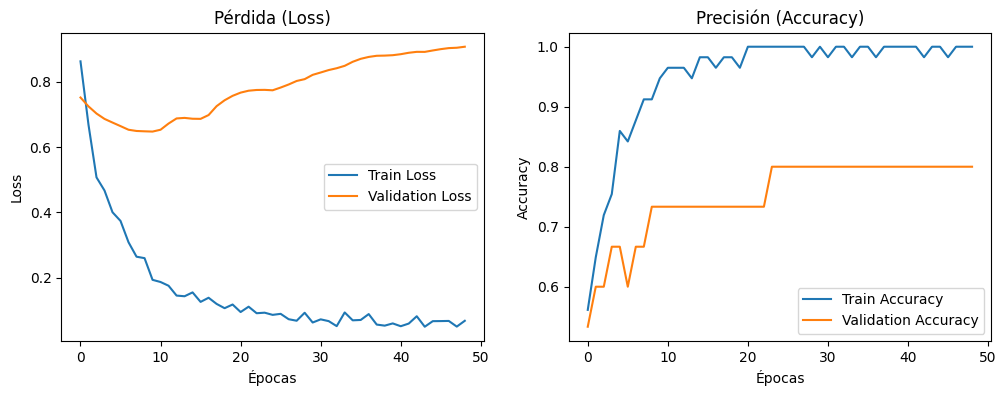

In [41]:
# GRÁFICAS DE LOSS Y ACCURACY


plt.figure(figsize=(12,4))

# Gráfica Loss
plt.subplot(1,2,1)

plt.plot(
    historia.history['loss'],
    label='Train Loss'
)

plt.plot(
    historia.history['val_loss'],
    label='Validation Loss'
)

plt.title('Pérdida (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

# Gráfica Accuracy
plt.subplot(1,2,2)

plt.plot(
    historia.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    historia.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Precisión (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

<a id='fase4'></a>
## Fase 4: Evaluación y Resultados

### Paso 4.1: Simulación de salida
Implementamos la lógica para interpretar la predicción del modelo.

In [42]:
# FASE 4.1: SIMULACIÓN DE SALIDA


def interpret_prediction(prediction):

    # Interpretar resultado
    if prediction > 0.5:

        return "Luz Encendida"

    else:

        return "Luz Apagada"


# Realizar predicción
prob = modelo_luz.predict(X_test[0:1])

print(f"\nProbabilidad: {prob[0][0]:.4f}")

print(
    f"Resultado: "
    f"{interpret_prediction(prob[0][0])}"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step

Probabilidad: 0.9868
Resultado: Luz Encendida


### Paso 4.2: Prueba ciega (voz del profesor)
Cargaremos un audio externo, aplicaremos el mismo preprocesamiento y evaluaremos el resultado para ver si el modelo generaliza correctamente.

In [43]:
# FASE 4.2: PRUEBA CIEGA


def predict_audio(file_path, model):

    # Aplicar mismo preprocesamiento
    features = extract_features(file_path)

    if features is not None:

        # Normalizar audio externo
        features = scaler.transform([features])

        # Realizar predicción
        prediction = model.predict(features)

        # Interpretar resultado
        result = interpret_prediction(
            prediction[0][0]
        )

        print(f"\nPredicción para: {file_path}")

        print(f"Resultado: {result}")

        print(
            f"Probabilidad de encendido: "
            f"{prediction[0][0]:.4f}"
        )

    else:

        print("No se pudo procesar el audio.")


# Ruta del audio del profesor
path_audio_profesor = '/content/drive/MyDrive/Librosa/apagarluz/Apagar_179169.wav'

# Ejecutar prueba
predict_audio(
    path_audio_profesor,
    modelo_luz
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step

Predicción para: /content/drive/MyDrive/Librosa/apagarluz/Apagar_179169.wav
Resultado: Luz Apagada
Probabilidad de encendido: 0.3259


<a id='conclusiones'></a>
## Conclusiones

Tras el desarrollo, entrenamiento y evaluación del modelo de reconocimiento de voz para el comando "Luz Inteligente", el equipo ha llegado a las siguientes conclusiones trabajando con los audios disponibles durante el desarrollo del proyecto.:

1. **Justificación de la Arquitectura Optimizada:** Inicialmente, un modelo muy complejo (múltiples capas densas con muchas neuronas) resultó en un desempeño estancado y propenso al sobreajuste debido a la cantidad limitada de audios en el dataset (58 procesados). Para solucionar esto, optamos por **simplificar la arquitectura a 1 capa oculta con 32 neuronas** e implementamos una capa **Dropout del 20%**. Esto permitió equilibrar la precisión de entrenamiento con la precisión de validación, evitando que el modelo memorizara los datos.
2. **Importancia del Preprocesamiento (MFCC):** La extracción de características mediante Coeficientes Cepstrales en Frecuencia Mel (MFCC) demostró ser fundamental. Transformar el audio crudo a una matriz (40x44) normalizada (Min-Max) permitió a la red neuronal procesar el espectro de frecuencias que realmente importan para la percepción humana del habla.
3. **Desafíos y Generalización:** En la prueba ciega observamos que factores como el tipo de micrófono, el ruido de fondo y la acústica de la habitación afectan la predicción. Sin embargo, la optimización de los hiperparámetros y el uso del Dropout ayudaron a que las curvas de pérdida (Loss) y precisión (Accuracy) se mantuvieran estables.
4. **Trabajo a Futuro:** Para mejorar la robustez de este sistema y llevar la precisión por encima del 90%, sería estrictamente necesario aumentar significativamente el tamaño del dataset (Data Augmentation) o recolectar un banco de voces más extenso que abarque distintas tonalidades y velocidades al hablar.



Tras realizar distintas pruebas con arquitecturas de 1, 2 y 3 capas ocultas, se observó que incrementar la complejidad del modelo aumentaba la precisión de entrenamiento, pero no mejoraba la precisión de validación. Esto indica un posible sobreajuste debido al tamaño reducido del dataset. Por ello, se eligió una arquitectura más simple de 1 capa oculta y 32 neuronas, buscando un mejor equilibrio entre simplicidad y estabilidad.